<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/AssociationRule_Apriori_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Association Rule

In [3]:
#To make sure the first row is not thought of as the heading

df = pd.read_csv('https://raw.githubusercontent.com/datadigger01/AppStatMat/main/Data/Market_Basket_Opt.csv', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [22]:
#Transforming the list into a list of lists, so that each transaction can be indexed easier
transactions = []
for i in range(0, df.shape[0]):
    transactions.append([str(df.values[i, j]) for j in range(0, 20)])

print(transactions[1])

['burgers', 'meatballs', 'eggs', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']


### Association Rule 수행을 위한 package 설치 - Apriori

In [23]:
!pip install apyori

### Apriori 알고리즘 수행하여 rule 도출

In [24]:
from apyori import apriori
# Please download this as a custom package --> type "apyori"

rules = apriori(transactions, min_support = 0.003, min_confidence = 0.2, min_lift = 3, min_length = 2)
# Support: number of transactions containing set of times / total number of transactions
# .      --> products that are bought at least 3 times a day --> 21 / 7501 = 0.0027
# Confidence: Should not be too high, as then this wil lead to obvious rules

#viewing the rules
results = list(rules)

In [33]:
results[0:5]

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)]),
 RelationRecord(items=frozenset({'mushroom cream sauce', 'escalope'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]),
 RelationRecord(items=frozenset({'escalope', 'pasta'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]),
 RelationRecord(items=frozenset({'honey', 'fromage blanc'}), support=0.003332888948140248, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confidence=0

In [30]:
# Function to extract details from the apriori results
def inspect_apriori_results(results):
    rh_list = [] # Right Hand Side
    lh_list = [] # Left Hand Side
    support_values = []
    confidence = []
    lift = []

    # Iterate through each RelationRecord in the results list
    for relation_record in results:
        # Access support directly from the RelationRecord
        current_support = relation_record.support

        # Each RelationRecord can have multiple OrderedStatistic objects
        for ordered_stat in relation_record.ordered_statistics:
            lh_list.append(tuple(ordered_stat.items_base))
            rh_list.append(tuple(ordered_stat.items_add))
            support_values.append(current_support)
            confidence.append(ordered_stat.confidence)
            lift.append(ordered_stat.lift)

    return lh_list, rh_list, support_values, confidence, lift

# Extract the data
lhs, rhs, supports, confidences, lifts = inspect_apriori_results(results)

# Create the result_df DataFrame
result_df = pd.DataFrame({
    'LHS': lhs,
    'RHS': rhs,
    'Support': supports,
    'Confidence': confidences,
    'Lift': lifts
})

# Display the first few rows of the created DataFrame
print("Created result_df (first 5 rows):")
print(result_df.head())

# Filter out rules containing 'nan' as they are not meaningful for further analysis or visualization
result_df_cleaned = result_df[~result_df['LHS'].apply(lambda x: 'nan' in str(x))]
result_df_cleaned = result_df_cleaned[~result_df_cleaned['RHS'].apply(lambda x: 'nan' in str(x))]

# You can also display the first few rows of the cleaned DataFrame
print("\nCleaned result_df (first 5 rows - 'nan' removed):")
print(result_df_cleaned.head())

Created result_df (first 5 rows):
                       LHS             RHS   Support  Confidence      Lift
0           (light cream,)      (chicken,)  0.004533    0.290598  4.843951
1  (mushroom cream sauce,)     (escalope,)  0.005733    0.300699  3.790833
2                 (pasta,)     (escalope,)  0.005866    0.372881  4.700812
3         (fromage blanc,)        (honey,)  0.003333    0.245098  5.164271
4         (herb & pepper,)  (ground beef,)  0.015998    0.323450  3.291994

Cleaned result_df (first 5 rows - 'nan' removed):
                       LHS             RHS   Support  Confidence      Lift
0           (light cream,)      (chicken,)  0.004533    0.290598  4.843951
1  (mushroom cream sauce,)     (escalope,)  0.005733    0.300699  3.790833
2                 (pasta,)     (escalope,)  0.005866    0.372881  4.700812
3         (fromage blanc,)        (honey,)  0.003333    0.245098  5.164271
4         (herb & pepper,)  (ground beef,)  0.015998    0.323450  3.291994


In [31]:
result_df_cleaned.sort_values(by='Confidence', ascending=False)

,LHS,RHS,Support,Confidence,Lift
180,"(soup, frozen vegetables, milk)","(mineral water,)",0.003066,0.766667,3.216312
15,"(cereals, ground beef)","(spaghetti,)",0.003066,0.676471,3.885303
89,"(olive oil, tomatoes)","(spaghetti,)",0.004399,0.611111,3.509912
181,"(soup, frozen vegetables, mineral water)","(milk,)",0.003066,0.605263,4.670863
69,"(tomato sauce, ground beef)","(spaghetti,)",0.003066,0.575000,3.302508
...,...,...,...,...,...
23,"(chicken, spaghetti)","(olive oil,)",0.003466,0.201550,3.060384
88,"(spaghetti, pancakes)","(olive oil,)",0.005066,0.201058,3.052910
118,"(ground beef, eggs)","(chocolate, mineral water)",0.003999,0.200000,3.797975
224,"(milk, ground beef)","(spaghetti, mineral water)",0.004399,0.200000,3.348661


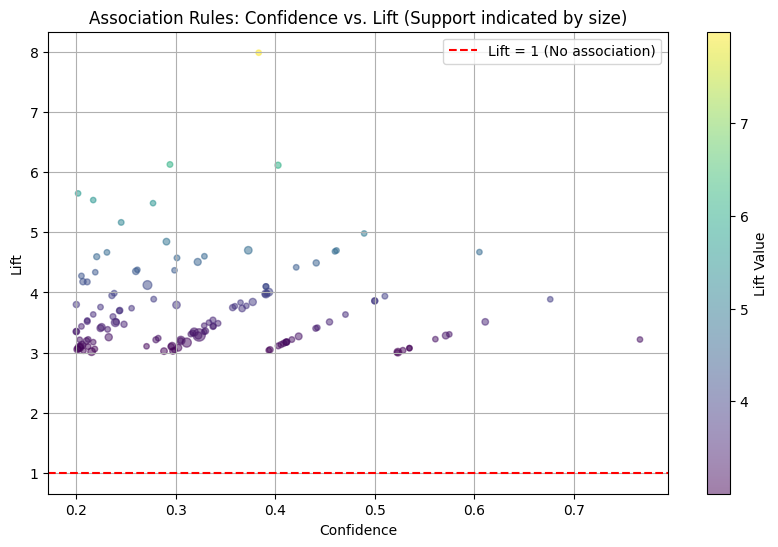

In [32]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(result_df_cleaned['Confidence'], result_df_cleaned['Lift'],
            s=result_df_cleaned['Support']*5000, # Scale support for better visibility
            alpha=0.5,
            c=result_df_cleaned['Lift'], # Color by lift
            cmap='viridis') # Choose a colormap

plt.title('Association Rules: Confidence vs. Lift (Support indicated by size)')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.colorbar(label='Lift Value')
plt.grid(True)
plt.axhline(y=1, color='r', linestyle='--', label='Lift = 1 (No association)')
plt.legend()
plt.show()